<div class="alert alert-success"><h1>L2 Regularization of a Deep Learning Model in Python</h1></div>

Regularization is a set of techniques designed to reduce overfitting in machine learning models. Overfitting occurs when a model performs exceptionally well on the training data but fails to generalize to unseen data. This often happens when the model becomes overly complex and starts memorizing the noise or irrelevant details in the training data, instead of learning the underlying patterns.

Regularization works by introducing constraints or penalties to the training process, limiting the model’s ability to fit the training data too closely. By controlling the complexity of the model, regularization helps strike a balance between underfitting and overfitting, resulting in better generalization performance.

## Learning Objectives
By the end of this tutorial, you will:
+ Know how to apply L2 regularization to a deep learning model.
+ Understand how to evaluate the impact of regularization on a deep learning model.


## Prerequisites
Before we begin, ensure you have:
+ Basic knowledge of Python programming (variables, functions, classes).
+ Familiarity with the fundamentals of how to build a deep learning model in Python using Keras.
+ A Python (version 3.x) environment with the `tensorflow`, `keras`, and `matplotlib` packages installed.

<div class="alert alert-success"><h2>1. Import and Preprocess the Data</h2></div>

We start by importing the data. For this tutorial, we'll use the **MNIST dataset**, a classic dataset in the machine learning community. It consists of 70,000 grayscale images of handwritten digits ranging from 0 to 9. Each image is 28 x 28 pixels, and the dataset is divided into 60,000 training images and 10,000 testing images. Our goal will be to develop a model that learns to correctly identify a handritten digit given the image.

In [ ]:
from tensorflow import keras

keras.utils.set_random_seed(1234)
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Our deep learning model expects the images as a vector of size 784 (i.e. 28 $\times$ 28). So, let's flatten the images.

In [ ]:
train_images = train_images.reshape(60000, 28 * 28)
test_images = test_images.reshape(10000, 28 * 28)

The model also expects the image pixel values scaled. Let's do that as well.

In [ ]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

Finally, we also need to one-hot encode the image labels.

In [ ]:
num_classes = 10
train_labels = keras.utils.to_categorical(train_labels, num_classes)
test_labels = keras.utils.to_categorical(test_labels, num_classes)

<div class="alert alert-success"><h2>2. Define the Baseline Model</h2></div>

The baseline model consists of an input layer with 784 nodes, two hidden layers with 512 and 128 nodes (respectively), and an output layer with 10 nodes.

In [ ]:
from tensorflow.keras.layers import Input, Dense

model = keras.Sequential([
    Input(shape = (784,)),
    Dense(512, activation = 'relu'),
    Dense(128, activation = 'relu'),
    Dense(10, activation = 'softmax')
])

<div class="alert alert-success"><h2>3. Compile and Train the Baseline Model</h2></div>

Next, we compile the baseline model, ...

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

... train the model, ...

In [ ]:
history = model.fit(
    train_images,
    train_labels,
    epochs = 15,
    batch_size = 128,
    validation_split = 0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8685 - loss: 0.4580 - val_accuracy: 0.9705 - val_loss: 0.0952
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9690 - loss: 0.1043 - val_accuracy: 0.9773 - val_loss: 0.0785
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9826 - loss: 0.0598 - val_accuracy: 0.9770 - val_loss: 0.0789
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9888 - loss: 0.0386 - val_accuracy: 0.9768 - val_loss: 0.0826
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9925 - loss: 0.0256 - val_accuracy: 0.9783 - val_loss: 0.0912
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9934 - loss: 0.0208 - val_accuracy: 0.9725 - val_loss: 0.1082
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9938 - loss: 0.0202 - val_accuracy: 0.9722 - val_loss: 0.1145
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9930 - loss: 0.0202 - val_accuracy: 0

... and plot the training and validation loss metrics.

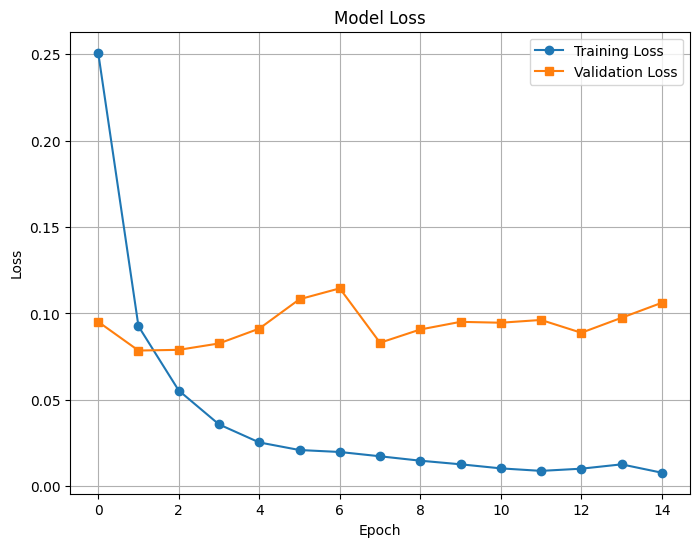

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize = (8, 6))
plt.plot(history.history['loss'], label = 'Training Loss', marker = 'o')
plt.plot(history.history['val_loss'], label = 'Validation Loss', marker = 's')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

A clear indicator of overfitting is the divergence in the training and validation loss metrics, which is visible in the training curves above.

<div class="alert alert-info"><b>Note:</b> To learn more about deep learning and how to build a deep learning model in Python using Keras, refer to  the LinkedIn Learning course titled <b>"Deep Learning with Python: Foundations"</b>.</div>

<div class="alert alert-success"><h2>4. Apply L2 Regularization to the Model</h2></div>

L2 (Ridge) Regularization adds a penalty proportional to the squared values of the weights. This discourages large weights, helping the model generalize better. Mathematically, the impact of L2 regularization on the loss function is defined as:
$$
\text{Loss} = \text{Original Loss} + \lambda \cdot \sum ^n _{i=1} w_i^2
$$

+ **$\lambda$:** is the regularization paremeter, controlling the strength of the penaly. Higher values of $\lambda$ lead to stronger regularization.
+ **$w_i^2$:** are the squared values of the weights.

To apply L2 regularization to the baseline model, we set the `kernel_regularizer` argument within each hidden layer of the network to `l2(0.001)`. This means that the regularization paremeter is set to $0.001$.

In [ ]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2

model_l2 = keras.Sequential([
    Input(shape = (784,)),
    Dense(512, activation = 'relu', kernel_regularizer = l2(0.001)),
    Dense(128, activation = 'relu', kernel_regularizer = l2(0.001)),
    Dense(10, activation = 'softmax')
])

Next, we compile the regularized model,...

In [ ]:
model_l2.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

... train the regularized model, ...

In [ ]:
history = model_l2.fit(
    train_images,
    train_labels,
    epochs = 15,
    batch_size = 128,
    validation_split = 0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8654 - loss: 0.9521 - val_accuracy: 0.9632 - val_loss: 0.3603
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9570 - loss: 0.3522 - val_accuracy: 0.9710 - val_loss: 0.2581
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9661 - loss: 0.2627 - val_accuracy: 0.9730 - val_loss: 0.2222
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9702 - loss: 0.2258 - val_accuracy: 0.9743 - val_loss: 0.2046
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9732 - loss: 0.2058 - val_accuracy: 0.9745 - val_loss: 0.1920
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9757 - loss: 0.1917 - val_accuracy: 0.9772 - val_loss: 0.1800
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9768 - loss: 0.1818 - val_accuracy: 0.9780 - val_loss: 0.1727
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9778 - loss: 0.1730 - val_accuracy: 0

... and plot the training and validation loss metrics.

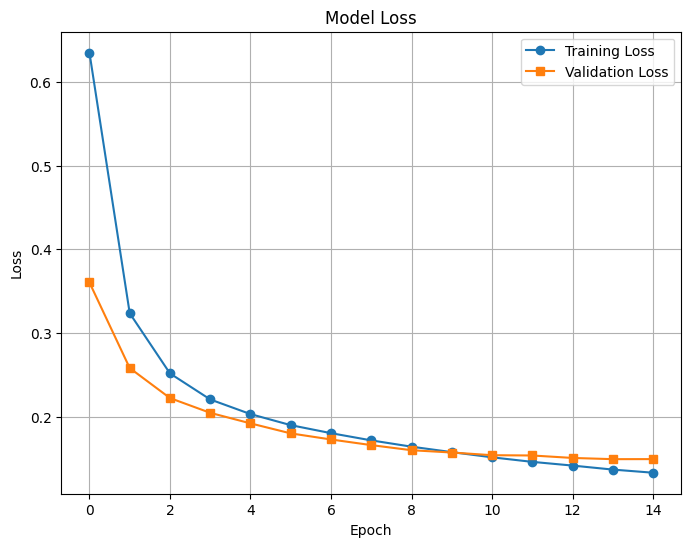

In [ ]:
plt.figure(figsize = (8, 6))
plt.plot(history.history['loss'], label = 'Training Loss', marker = 'o')
plt.plot(history.history['val_loss'], label = 'Validation Loss', marker = 's')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

This time, we see that the model's training and validation loss metrics tend to decrease at a similar rate throughout the training process. This is a strong indication that L2 regularization is effectively reducing overfitting by discouraging the model from relying too heavily on large weight values.

By adding a penalty proportional to the squared magnitude of the weights, L2 regularization ensures that the model focuses on learning patterns that generalize well to unseen data rather than memorizing the training data.

The similarity in the rate of decrease for both metrics indicates that the model is improving its performance on both the training and validation datasets without overfitting. This balanced behavior suggests that the L2 penalty is successfully constraining the complexity of the model, allowing it to capture meaningful relationships in the data while avoiding over-reliance on specific features or noise.